# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does
1. Parses annotations → extracts **5s windows centered on each signal** (label = annotation label)
2. Extracts **fixed 5s background windows** from gap regions in each file (label = `background`)
3. Embeds all windows with **Perch V2**
4. Evaluates **zero-shot** performance using Perch V2's built-in logits
5. Trains a **linear classifier** on top of the embeddings
6. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

In [3]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0:1], 'GPU')
    # Optional: prevent TF from grabbing all memory
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    f1_score, precision_recall_fscore_support
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

2026-04-30 10:44:32.762777: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-30 10:44:35.047606: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-30 10:44:42.313105: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/dclde_2013/source-audio'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/dclde_2013'

#@markdown Path to your single annotation JSON file
annotation_json_path = '/data2/mromaniuc/cet-det/datasets/dclde_2013/fiwh_annotations.json'  #@param {type:'string'}

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [6]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1777531304.718752 4172269 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1777531304.720440 4172269 gpu_device.cc:2020] Created device /device:GPU:1 with 20749 MB memory:  -> device: 1, name: NVIDIA L4, pci bus id: 0000:5e:00.0, compute capability: 8.9
I0000 00:00:1777531305.321438 4172269 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


In [7]:
#@title Parse annotations and build window list
import json
import pandas as pd
import numpy as np
from pathlib import Path
import librosa
from datetime import timezone
from tqdm import tqdm
# ── Load annotations ──────────────────────────────────────────────────────────
with open(annotation_json_path) as f:
    annot_records = json.load(f)

annot_df = pd.DataFrame(annot_records)
annot_df['start_dt'] = pd.to_datetime(annot_df['start_dt'], utc=True)
annot_df['end_dt']   = pd.to_datetime(annot_df['end_dt'],   utc=True)

print(f'Loaded {len(annot_df)} FIWH annotations')
print(f'Time range: {annot_df.start_dt.min()} → {annot_df.start_dt.max()}')

def parse_wav_start_time(wav_path):
    from datetime import datetime, timezone
    stem  = Path(wav_path).stem
    parts = stem.split('_')
    # NOPP6_EST_20090328_001500_CH10
    date_str = parts[2]  # 20090328
    time_str = parts[3]  # 001500
    dt_naive = datetime.strptime(date_str + time_str, '%Y%m%d%H%M%S')
    # filename says EST = UTC-5, convert to UTC
    dt_utc   = dt_naive.replace(tzinfo=timezone.utc) + pd.Timedelta(hours=5)
    return pd.Timestamp(dt_utc)

# ── Build windows ─────────────────────────────────────────────────────────────
wav_folder_path = Path(wav_folder)
wav_files       = sorted(wav_folder_path.glob('*.wav'))
print(f'\nFound {len(wav_files)} wav files')

windows      = []
missing_time = []
skipped      = []

for wav_path in tqdm(wav_files, desc='Building windows'):
    try:
        file_start_utc = parse_wav_start_time(wav_path)
    except Exception as e:
        skipped.append((wav_path.name, str(e)))
        continue

    try:
        duration = librosa.get_duration(path=str(wav_path))
    except Exception as e:
        skipped.append((wav_path.name, str(e)))
        continue

    file_end_utc = file_start_utc + pd.Timedelta(seconds=duration)
    n_windows    = int(duration // window_size_s)

    file_annots = annot_df[
        (annot_df['start_dt'] < file_end_utc) &
        (annot_df['end_dt']   > file_start_utc)
    ]

    for i in range(n_windows):
        win_start_utc = file_start_utc + pd.Timedelta(seconds=i * window_size_s)
        win_end_utc   = win_start_utc  + pd.Timedelta(seconds=window_size_s)
        offset_s      = i * window_size_s

        overlaps = (
            (file_annots['end_dt']   > win_start_utc) &
            (file_annots['start_dt'] < win_end_utc)
        )
        overlap_s = (
            (file_annots['end_dt'].clip(upper=win_end_utc) -
             file_annots['start_dt'].clip(lower=win_start_utc))
            .dt.total_seconds()
            .clip(lower=0)
        )
        label = 'FIWH' if (overlap_s >= min_overlap_s).any() else 'background'

        windows.append({
            'wav_path':      str(wav_path),
            'offset_s':      offset_s,
            'win_start_utc': win_start_utc.isoformat(),
            'win_end_utc':   win_end_utc.isoformat(),
            'label':         label,
        })

windows_df = pd.DataFrame(windows)

print(f'\nTotal windows : {len(windows_df)}')
if skipped:
    print(f'Skipped files : {len(skipped)} — {skipped[:3]}')
print('\nClass distribution:')
print(windows_df['label'].value_counts())
print(f'\nPositive rate: {100 * (windows_df.label == "FIWH").mean():.2f}%')

Loaded 52400 FIWH annotations
Time range: 2009-03-28 05:01:26+00:00 → 2009-04-04 04:49:20+00:00

Found 672 wav files


Building windows: 100%|██████████| 672/672 [03:12<00:00,  3.48it/s]


Total windows : 120960

Class distribution:
label
background    74907
FIWH          46053
Name: count, dtype: int64

Positive rate: 38.07%


just to check wether we correctly assigned the labels:

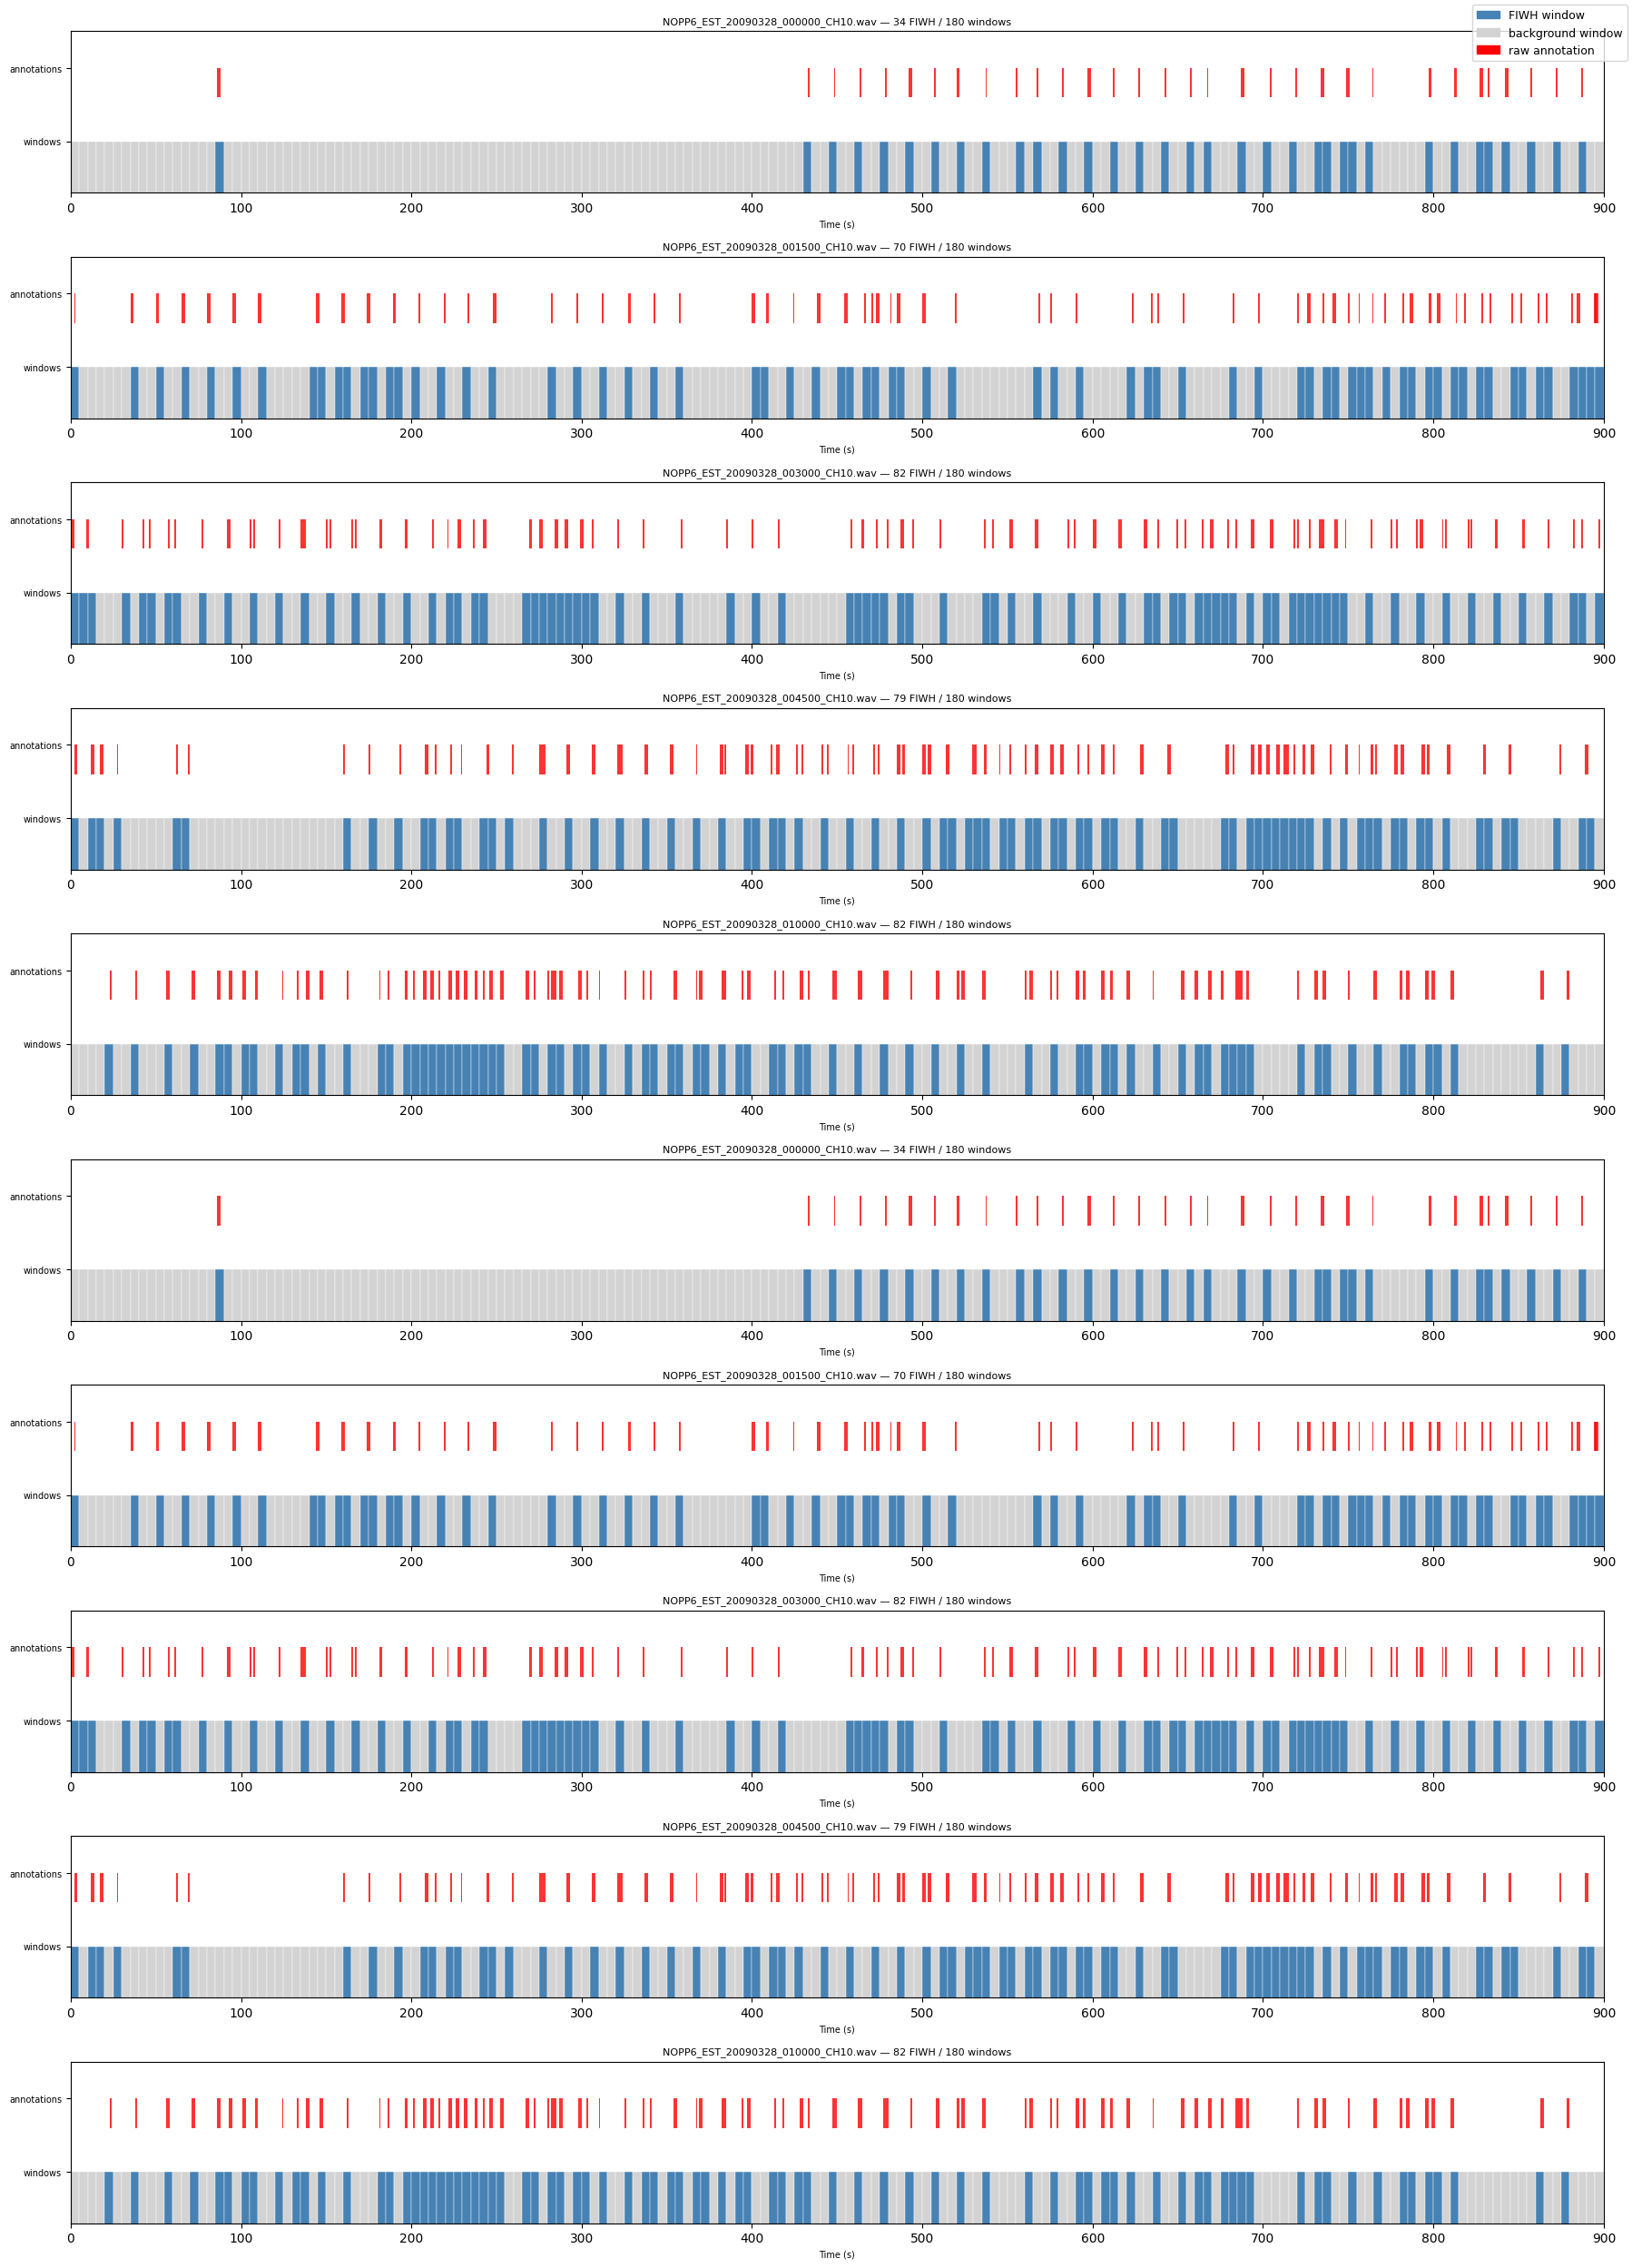

Saved → /data2/mromaniuc/cet-det/models/perch_v2/DCLDE_2013/figures/visualize_windows.png


In [8]:
#@title Visualize window labels per file (subset)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import os

N_FILES_TO_PLOT = 10  # adjust as needed — don't plot all 672

files    = windows_df['wav_path'].unique()
n_files  = min(N_FILES_TO_PLOT, len(files))

# pick a mix — some files with FIWH, some without
fiwh_files  = windows_df[windows_df['label'] == 'FIWH']['wav_path'].unique()
bg_files    = windows_df[windows_df['label'] == 'background']['wav_path'].unique()
subset      = list(fiwh_files[:n_files // 2]) + list(bg_files[:n_files // 2])
subset      = subset[:n_files]

fig, axes = plt.subplots(len(subset), 1, figsize=(18, 2.5 * len(subset)))
if len(subset) == 1:
    axes = [axes]

for ax, wav_path in zip(axes, subset):
    file_windows = windows_df[windows_df['wav_path'] == wav_path].copy()
    duration     = file_windows['offset_s'].max() + window_size_s

    # ── draw 5s windows as colored bars ──────────────────────────────────
    for _, row in file_windows.iterrows():
        color = 'steelblue' if row['label'] == 'FIWH' else 'lightgray'
        ax.barh(0, window_size_s, left=row['offset_s'], height=0.5,
                color=color, edgecolor='white', linewidth=0.3)

    # ── overlay raw FIWH annotation intervals ────────────────────────────
    file_start_utc = parse_wav_start_time(wav_path)
    file_annots    = annot_df[
        (annot_df['start_dt'] < file_start_utc + pd.Timedelta(seconds=duration)) &
        (annot_df['end_dt']   > file_start_utc)
    ]
    for _, ann in file_annots.iterrows():
        # convert UTC annotation time to offset within file
        ann_start_s = (ann['start_dt'] - file_start_utc).total_seconds()
        ann_end_s   = (ann['end_dt']   - file_start_utc).total_seconds()
        ax.barh(0.65, ann_end_s - ann_start_s, left=ann_start_s,
                height=0.2, color='red', alpha=0.8)

    ax.set_xlim(0, duration)
    ax.set_ylim(-0.1, 1.0)
    ax.set_yticks([0.25, 0.75])
    ax.set_yticklabels(['windows', 'annotations'], fontsize=7)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.set_title(
        f'{Path(wav_path).name} — '
        f'{(file_windows.label == "FIWH").sum()} FIWH / '
        f'{len(file_windows)} windows',
        fontsize=8
    )

# legend
fiwh_patch = mpatches.Patch(color='steelblue', label='FIWH window')
bg_patch   = mpatches.Patch(color='lightgray', label='background window')
ann_patch  = mpatches.Patch(color='red',       label='raw annotation')
fig.legend(handles=[fiwh_patch, bg_patch, ann_patch],
           loc='upper right', fontsize=9)

plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/visualize_windows.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Saved → {save_dir}/figures/visualize_windows.png')

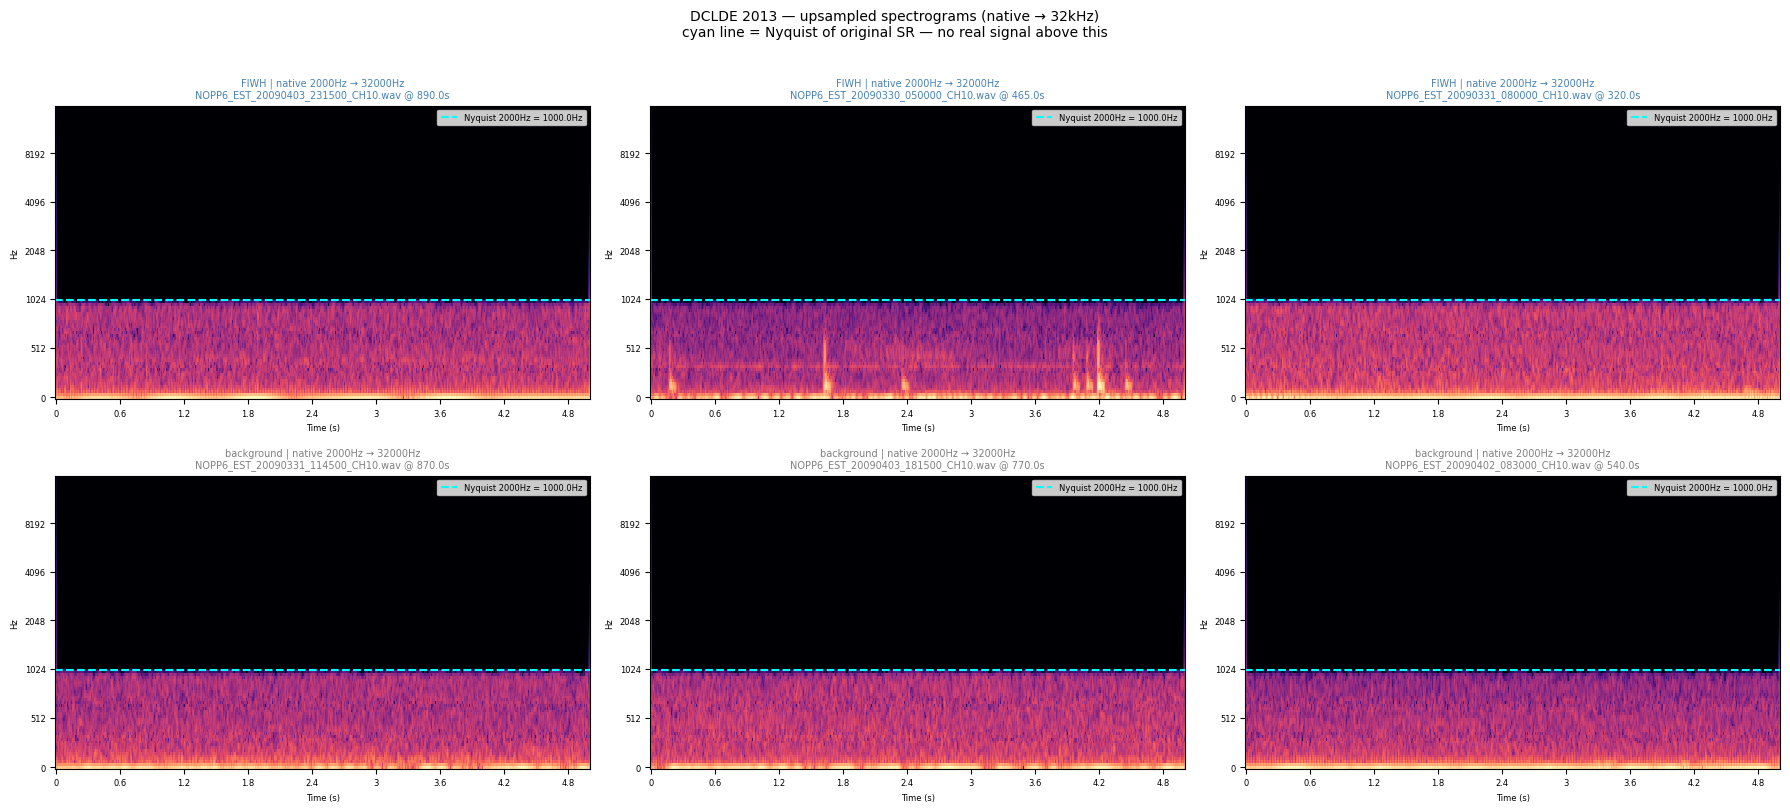

Saved → /data2/mromaniuc/cet-det/models/perch_v2/DCLDE_2013/figures/upsampled_spectrogram_qc.png


In [9]:
#@title QC Spectrograms — 2kHz → 32kHz upsampled windows
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soxr
from pathlib import Path

N_SPEC = 3  # examples per class
TARGET_SR     = 32000
TARGET_SAMPLES = int(window_size_s * TARGET_SR)

# pick N_SPEC FIWH and N_SPEC background windows
fiwh_sample = windows_df[windows_df['label'] == 'FIWH'].sample(N_SPEC, random_state=42)
bg_sample   = windows_df[windows_df['label'] == 'background'].sample(N_SPEC, random_state=42)
samples     = pd.concat([fiwh_sample, bg_sample]).reset_index(drop=True)

fig, axes = plt.subplots(2, N_SPEC, figsize=(18, 8))

for col in range(N_SPEC):
    for row, label_class in enumerate(['FIWH', 'background']):
        ax  = axes[row][col]
        rec = samples[samples['label'] == label_class].iloc[col]

        try:
            # load at native SR
            audio_native, native_sr = librosa.load(
                rec['wav_path'], sr=None,
                offset=rec['offset_s'], duration=window_size_s, mono=True
            )

            # upsample to 32kHz
            audio_32k = soxr.resample(audio_native, native_sr, TARGET_SR)
            if len(audio_32k) < TARGET_SAMPLES:
                audio_32k = np.pad(audio_32k, (0, TARGET_SAMPLES - len(audio_32k)))
            audio_32k = audio_32k[:TARGET_SAMPLES].astype(np.float32)

            # mel spectrogram
            S    = librosa.feature.melspectrogram(
                y=audio_32k, sr=TARGET_SR,
                n_mels=128, fmin=0, fmax=TARGET_SR // 2,
                hop_length=160, n_fft=1024
            )
            S_db = librosa.power_to_db(S, ref=np.max)

            librosa.display.specshow(
                S_db, sr=TARGET_SR, hop_length=160,
                fmin=0, fmax=TARGET_SR // 2,
                x_axis='time', y_axis='mel',
                ax=ax, cmap='magma'
            )

            ax.set_title(
                f'{label_class} | native {native_sr}Hz → {TARGET_SR}Hz\n'
                f'{Path(rec["wav_path"]).name} @ {rec["offset_s"]:.1f}s',
                fontsize=7,
                color='steelblue' if label_class == 'FIWH' else 'gray'
            )
            ax.set_xlabel('Time (s)', fontsize=6)
            ax.set_ylabel('Hz',       fontsize=6)
            ax.tick_params(labelsize=6)

            # draw a line at the Nyquist of the original SR
            # above this line there is NO real information
            nyquist_original = native_sr / 2
            ax.axhline(y=nyquist_original, color='cyan', linewidth=1.5,
                       linestyle='--', label=f'Nyquist {native_sr}Hz = {nyquist_original}Hz')
            ax.legend(fontsize=6, loc='upper right')

        except Exception as e:
            ax.set_title(f'ERROR\n{str(e)[:40]}', fontsize=7)
            ax.axis('off')

plt.suptitle(
    f'DCLDE 2013 — upsampled spectrograms (native → 32kHz)\n'
    f'cyan line = Nyquist of original SR — no real signal above this',
    fontsize=10, y=1.01
)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/upsampled_spectrogram_qc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_dir}/figures/upsampled_spectrogram_qc.png')

In [10]:
import soxr
from tqdm import tqdm
import os
import numpy as np

embeddings_list, logits_list, labels_list, failed_idx = [], [], [], []
windows_df = windows_df.reset_index(drop=True)

for i, row in tqdm(windows_df.iterrows(), total=len(windows_df)):
    try:
        audio_native, native_sr = librosa.load(
            row['wav_path'], sr=None,
            offset=row['offset_s'], duration=window_size_s, mono=True
        )
        audio      = soxr.resample(audio_native, native_sr, sr)
        target_len = int(window_size_s * sr)
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)))
        audio = audio[:target_len].astype(np.float32)

        out = embedding_model.embed(audio)
        embeddings_list.append(out.embeddings[0].mean(axis=0))
        logits_list.append(out.logits['label'][0])
        labels_list.append(row['label'])

    except Exception as e:
        failed_idx.append(i)
        print(f'  FAILED [{i}] {Path(row["wav_path"]).name} @ {row["offset_s"]:.1f}s — {repr(e)}')


X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)

print(f'\nDone. {len(X)} embedded, {len(failed_idx)} failed.')
print(f'Embedding shape : {X.shape}')
print(f'Logits shape    : {Z.shape}')

# ── NaN diagnostic ────────────────────────────────────────────────────────────
nan_in_X = np.isnan(X).any(axis=1)
nan_in_Z = np.isnan(Z).any(axis=1)
nan_any  = nan_in_X | nan_in_Z

print(f'\n=== NaN DIAGNOSTIC ===')
print(f'Rows with NaN in X     : {nan_in_X.sum()}')
print(f'Rows with NaN in Z     : {nan_in_Z.sum()}')
print(f'Rows with NaN in either: {nan_any.sum()}')

if nan_any.sum() > 0:
    pct = nan_any.sum() / len(X) * 100
    if pct < 5.0:
        print(f'{nan_any.sum()} NaN rows ({pct:.2f}%) — dropping.')
        valid = ~nan_any
        X, Z, y = X[valid], Z[valid], y[valid]
        windows_df = windows_df[valid].reset_index(drop=True)
    else:
        print(f'WARNING: {pct:.2f}% NaN — investigate before training.')
else:
    print('No NaN values — data is clean.')

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs(f'{save_dir}/embeddings', exist_ok=True)

metadata_save = windows_df.copy()
metadata_save['embedding_idx'] = metadata_save.index

np.save(f'{save_dir}/embeddings/X_embeddings.npy', X)
np.save(f'{save_dir}/embeddings/Z_logits.npy',     Z)
np.save(f'{save_dir}/embeddings/y_labels.npy',     y)
metadata_save.to_csv(f'{save_dir}/embeddings/metadata.csv', index=False)

print(f'\n=== SAVED TO {save_dir}/embeddings/ ===')
print(f'  X_embeddings.npy : {X.shape}')
print(f'  Z_logits.npy     : {Z.shape}')
print(f'  y_labels.npy     : {y.shape}')
print(f'\nClass distribution:')
print(pd.Series(y).value_counts())

  0%|          | 0/120960 [00:00<?, ?it/s]

2026-04-30 08:47:03.369754: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fe8fc06de40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-30 08:47:03.369792: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-04-30 08:47:03.688216: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-30 08:47:03.734338: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92100
2026-04-30 08:47:04.617000: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_55', 68 bytes spill stores, 68 bytes spill loads

2026-04-30 08:47:04.896723: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Regist


Done. 120960 embedded, 0 failed.
Embedding shape : (120960, 1536)
Logits shape    : (120960, 14795)

=== NaN DIAGNOSTIC ===
Rows with NaN in X     : 0
Rows with NaN in Z     : 0
Rows with NaN in either: 0
No NaN values — data is clean.

=== SAVED TO /data2/mromaniuc/cet-det/models/perch_v2/DCLDE_2013/embeddings/ ===
  X_embeddings.npy : (120960, 1536)
  Z_logits.npy     : (120960, 14795)
  y_labels.npy     : (120960,)

Class distribution:
background    74907
FIWH          46053
Name: count, dtype: int64


# retrieving the data and performing zero-shot and fully-supervised classifications

In [5]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')   # (9209, 1536)
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   # (9209,)
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   # (9209,)

metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (120960, 1536), Z: (120960, 14795), y: (120960,)
Class distribution:
background    74907
FIWH          46053
Name: count, dtype: int64


In [12]:
#@title Zero-shot species analysis — what does Perch think your sounds are?

# Get the class names in order
class_names_list = list(embedding_model.class_list['labels'].classes)

# Separate FIWH and background logits
fiwh_mask       = y_clean == 'FIWH'
background_mask = y_clean == 'background'

Z_fiwh       = Z_clean[fiwh_mask]
Z_background = Z_clean[background_mask]

# Mean logit per class
mean_logits_fiwh       = Z_fiwh.mean(axis=0)
mean_logits_background = Z_background.mean(axis=0)

# Top 20 classes for FIWH
top_fiwh_idx = np.argsort(mean_logits_fiwh)[::-1][:20]
print('TOP 20 PERCH CLASSES FOR FIWH WINDOWS:')
print('-' * 50)
for idx in top_fiwh_idx:
    print(f'  {mean_logits_fiwh[idx]:6.3f}  {class_names_list[idx]}')

print()

# Top 20 classes for background
top_background_idx = np.argsort(mean_logits_background)[::-1][:20]
print('TOP 20 PERCH CLASSES FOR BACKGROUND WINDOWS:')
print('-' * 50)
for idx in top_background_idx:
    print(f'  {mean_logits_background[idx]:6.3f}  {class_names_list[idx]}')

print()

# Classes to investigate
fiwh_candidates = {
    'FIWH': class_names_list.index('Balaenoptera physalus'),
}

background_candidates = {
    'Water':                  class_names_list.index('Water'),
    'Ocean':                  class_names_list.index('Ocean'),
    'Boat_and_Water_vehicle': class_names_list.index('Boat_and_Water_vehicle'),
}

print('\nFIWH CANDIDATES — mean logit for FIWH vs background windows:')
print('-' * 70)
for name, idx in fiwh_candidates.items():
    f_logit = mean_logits_fiwh[idx]
    b_logit = mean_logits_background[idx]
    f_rank  = np.where(np.argsort(mean_logits_fiwh)[::-1]       == idx)[0][0] + 1
    b_rank  = np.where(np.argsort(mean_logits_background)[::-1] == idx)[0][0] + 1
    print(f'  {name:30s}  FIWH: {f_logit:6.3f} (#{f_rank:4d})   background: {b_logit:6.3f} (#{b_rank:4d})   gap: {f_logit - b_logit:+.3f}')

print('\nBACKGROUND CANDIDATES — mean logit for background vs FIWH windows:')
print('-' * 70)
for name, idx in background_candidates.items():
    f_logit = mean_logits_fiwh[idx]
    b_logit = mean_logits_background[idx]
    b_rank  = np.where(np.argsort(mean_logits_background)[::-1] == idx)[0][0] + 1
    f_rank  = np.where(np.argsort(mean_logits_fiwh)[::-1]       == idx)[0][0] + 1
    print(f'  {name:30s}  background: {b_logit:6.3f} (#{b_rank:4d})   FIWH: {f_logit:6.3f} (#{f_rank:4d})   gap: {b_logit - f_logit:+.3f}')

TOP 20 PERCH CLASSES FOR FIWH WINDOWS:
--------------------------------------------------
   6.342  Strix aluco
   5.945  Bubo virginianus
   5.891  Aegolius acadicus
   5.426  Bubo bubo
   5.422  Aegolius funereus
   5.385  Strix uralensis
   5.269  Strix varia
   5.008  Wind
   4.987  Vulpes vulpes
   4.925  Megascops asio
   4.615  Strix nebulosa
   4.611  Strix virgata
   4.593  Canis latrans
   4.481  Asio otus
   4.415  Vulpes lagopus
   4.304  Turdus migratorius
   4.281  Cardinalis cardinalis
   4.266  Vehicle
   4.243  Corvus corax
   4.231  Animal

TOP 20 PERCH CLASSES FOR BACKGROUND WINDOWS:
--------------------------------------------------
   6.320  Strix aluco
   5.975  Aegolius acadicus
   5.901  Bubo virginianus
   5.446  Aegolius funereus
   5.377  Bubo bubo
   5.318  Strix uralensis
   5.128  Strix varia
   4.968  Vulpes vulpes
   4.941  Wind
   4.904  Megascops asio
   4.607  Strix virgata
   4.602  Strix nebulosa
   4.509  Canis latrans
   4.404  Asio otus
   4.393 

In [13]:
#@title Train / test split
le = LabelEncoder()
y_enc = le.fit_transform(y_clean)
class_names = list(le.classes_)
print('Classes:', class_names)

X_train, X_test, y_train, y_test, Z_train, Z_test = train_test_split(
    X_clean, y_enc, Z_clean,
    test_size=test_size,
    random_state=random_seed,
    stratify=y_enc
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Classes: ['FIWH', 'background']
Train: 84672  |  Test: 36288


In [14]:
#@title Zero-shot evaluation (Perch V2 built-in logits)
#@markdown Perch V2 was trained on bird/mammal/etc. taxonomy — 'FIWH' and 'background'
#@markdown are not in its class list, so zero-shot will likely score poorly unless you
#@markdown manually map your labels to the closest Perch species below.
#@markdown
#@markdown Example: label_to_perch = {'FIWH': 'Balaenoptera physalus', 'background': None}
#@markdown Set a label to None to exclude it (scores -inf, always loses).

label_to_perch = {'FIWH': 'Balaenoptera physalus', 'background': 'Water'}

def auto_match(label, perch_names):
    """Substring match — edit label_to_perch manually for better results."""
    label_lower = label.lower()
    for name in perch_names:
        if label_lower in name.lower() or name.lower() in label_lower:
            return name
    return None

final_mapping = {}
for cls in class_names:
    final_mapping[cls] = label_to_perch.get(cls, auto_match(cls, perch_class_names))

print('Label → Perch V2 class mapping:')
for k, v in final_mapping.items():
    status = '✓' if v else '✗ NOT FOUND'
    print(f'  {k:30s} → {str(v):40s} {status}')

def zero_shot_predict(Z_subset):
    preds = []
    for logits in Z_subset:
        scores = {}
        for cls in class_names:
            pname = final_mapping.get(cls)
            scores[cls] = logits[perch_class_names.index(pname)] if pname and pname in perch_class_names else -np.inf
        preds.append(max(scores, key=scores.get))
    return le.transform(preds)

y_pred_zs = zero_shot_predict(Z_test)

print('\n' + '='*60)
print('ZERO-SHOT (Perch V2 built-in logits)')
print('='*60)
print(classification_report(y_test, y_pred_zs, target_names=class_names))

Label → Perch V2 class mapping:
  FIWH                           → Balaenoptera physalus                    ✓
  background                     → Water                                    ✓

ZERO-SHOT (Perch V2 built-in logits)
              precision    recall  f1-score   support

        FIWH       0.00      0.00      0.00     13816
  background       0.62      1.00      0.76     22472

    accuracy                           0.62     36288
   macro avg       0.31      0.50      0.38     36288
weighted avg       0.38      0.62      0.47     36288



/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [15]:
#@title Train classifiers + track ROC-AUC & overfitting metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import time

# Pre-scale once to avoid redundant scaling inside pipelines (speeds up XGBoost eval)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=random_seed, class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=10, random_state=random_seed, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1))
    ])
}

results = {}
roc_data = {}

for name, pipeline in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    # Handle XGBoost separately to enable per-round evaluation
    if 'XGBoost' in name:
        xgb = pipeline.named_steps['clf']
        xgb.fit(X_train_sc, y_train,
                eval_set=[(X_train_sc, y_train), (X_test_sc, y_test)],
                eval_metric='logloss',
                verbose=False)
        y_pred = xgb.predict(X_test_sc)
        y_proba = xgb.predict_proba(X_test_sc)[:, 1]
        evals_result = xgb.evals_result()
        elapsed = time.time() - t0
    else:
        # Replace internal scaler with pre-scaled data to avoid double scaling
        pipe_copy = Pipeline([('clf', pipeline.named_steps['clf'])])
        pipe_copy.fit(X_train_sc, y_train)
        y_pred = pipe_copy.predict(X_test_sc)

        # Get probabilities or decision scores
        if hasattr(pipe_copy, 'predict_proba'):
            y_proba = pipe_copy.predict_proba(X_test_sc)[:, 1]
        else:
            y_proba = pipe_copy.decision_function(X_test_sc)

        elapsed = time.time() - t0

    # Metrics
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(len(class_names)))
    train_acc = pipe_copy.score(X_train_sc, y_train) if 'XGBoost' not in name else xgb.score(X_train_sc, y_train)
    test_acc = pipe_copy.score(X_test_sc, y_test) if 'XGBoost' not in name else xgb.score(X_test_sc, y_test)
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results[name] = {
        'y_pred': y_pred, 'y_proba': y_proba, 'pipeline': pipe_copy if 'XGBoost' not in name else xgb,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'time_s': elapsed, 'evals_result': evals_result if 'XGBoost' in name else None
    }
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Macro F1: {f1_macro:.4f} | ROC AUC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

# Summary table
print('\n' + '='*95)
print('SUMMARY — MACRO F1 + ROC AUC + OVERFITTING CHECK')
print('='*95)
print(f'{"Classifier":<20} {"Macro F1":>8} {"ROC AUC":>8} {"Train Acc":>10} {"Test Acc":>10} {"Gap":>6} {"Time(s)":>8}')
print('-'*95)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<20} {res["f1_macro"]:>8.4f} {roc_data[name]["auc"]:>8.4f} {res["train_acc"]:>10.4f} {res["test_acc"]:>10.4f} {gap:>6.4f} {res["time_s"]:>8.1f}')


Training Logistic Regression...
  Time: 28.4s | Train Acc: 0.6888 | Test Acc: 0.6713 | Macro F1: 0.6537 | ROC AUC: 0.7135
              precision    recall  f1-score   support

        FIWH       0.57      0.59      0.58     13816
  background       0.74      0.72      0.73     22472

    accuracy                           0.67     36288
   macro avg       0.65      0.65      0.65     36288
weighted avg       0.67      0.67      0.67     36288


Training Decision Tree...
  Time: 173.6s | Train Acc: 0.6935 | Test Acc: 0.6104 | Macro F1: 0.5976 | ROC AUC: 0.6420
              precision    recall  f1-score   support

        FIWH       0.49      0.57      0.53     13816
  background       0.71      0.64      0.67     22472

    accuracy                           0.61     36288
   macro avg       0.60      0.60      0.60     36288
weighted avg       0.62      0.61      0.61     36288


Training Random Forest...
  Time: 28.2s | Train Acc: 1.0000 | Test Acc: 0.6962 | Macro F1: 0.6061 | ROC 

In [21]:
#@title PyTorch MLP with Dropout — binary (FIWH vs background)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    roc_curve, accuracy_score
)
import numpy as np
import copy
import time

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (256,128) drop=0.5': {
        'hidden': (256, 128), 'dropout': 0.5, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
}

# ── Model builder ─────────────────────────────────────────────────────────────
def build_mlp(input_dim, hidden_sizes, dropout):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)

# ── Batched inference — never loads full dataset onto GPU ─────────────────────
def predict_batched(model, X_cpu, device, batch_size=1024):
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(X_cpu), batch_size):
            xb = X_cpu[i:i + batch_size].to(device)
            outs.append(model(xb).squeeze(1).cpu())
    return torch.cat(outs)

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # use GPU 1 — GPU 0 may be occupied
    print(f'Using GPU 1: {torch.cuda.get_device_name(device)}')
    free_mem = torch.cuda.mem_get_info(device)[0] / 1e9
    print(f'Free memory on GPU 1: {free_mem:.1f} GB')
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f'Using GPU 0: {torch.cuda.get_device_name(device)}')
else:
    device = torch.device('cpu')
    print('Using CPU')

torch.cuda.empty_cache()

# ── Data prep ─────────────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 0=FIWH, 1=background — but for binary BCE we want FIWH=1 (positive class)
# so flip: FIWH→1, background→0
y_train_bin = (y_train == 0).astype(np.float32)  # 0=FIWH → 1, 1=background → 0
y_test_bin  = (y_test  == 0).astype(np.float32)

print(f"Train — background: {(y_train_bin == 0).sum()}  FIWH: {(y_train_bin == 1).sum()}")
print(f"Test  — background: {(y_test_bin  == 0).sum()}  FIWH: {(y_test_bin  == 1).sum()}")

n_bg       = (y_train_bin == 0).sum()  # background is now 0
n_fiwh     = (y_train_bin == 1).sum()  # FIWH is now 1
pos_weight = torch.tensor([n_bg / n_fiwh], dtype=torch.float32).to(device)
print(f'pos_weight: {pos_weight.item():.3f}')

# ── Training loop ─────────────────────────────────────────────────────────────
mlp_results  = {}
mlp_roc_data = {}

for name, cfg in torch_mlp_configs.items():
    print(f'\n{"="*70}')
    print(f'Training {name}')
    print(f'{"="*70}')
    torch.cuda.empty_cache()
    t0 = time.time()

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train_bin, test_size=0.15,
        random_state=random_seed, stratify=y_train_bin
    )

    # keep ALL data on CPU — only batches go to GPU
    X_tr_cpu  = torch.tensor(X_tr,      dtype=torch.float32)
    y_tr_cpu  = torch.tensor(y_tr,      dtype=torch.float32)
    X_val_cpu = torch.tensor(X_val,     dtype=torch.float32)
    y_val_cpu = torch.tensor(y_val,     dtype=torch.float32)
    X_te_cpu  = torch.tensor(X_test_sc, dtype=torch.float32)
    y_te_cpu  = torch.tensor(y_test_bin,dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(X_tr_cpu, y_tr_cpu),
        batch_size=cfg['batch_size'], shuffle=True,
        num_workers=4, pin_memory=True  # pin_memory speeds up CPU→GPU transfer
    )

    input_dim = X_train_sc.shape[1]
    model     = build_mlp(input_dim, cfg['hidden'], cfg['dropout']).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay']
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None
    best_epoch       = 0
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(1, cfg['epochs'] + 1):
        # ── train ────────────────────────────────────────────────────────
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb).squeeze(1), yb).backward()
            optimizer.step()

        # ── eval — batched, never OOM ─────────────────────────────────────
        model.eval()
        tr_logits  = predict_batched(model, X_tr_cpu,  device)
        val_logits = predict_batched(model, X_val_cpu, device)

        y_tr_t  = y_tr_cpu
        y_val_t = y_val_cpu

        tr_loss  = nn.BCEWithLogitsLoss()(tr_logits,  y_tr_t).item()
        val_loss = nn.BCEWithLogitsLoss()(val_logits, y_val_t).item()
        tr_acc   = ((tr_logits  > 0) == y_tr_t.bool()).float().mean().item()
        val_acc  = ((val_logits > 0) == y_val_t.bool()).float().mean().item()

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_epoch       = epoch
            best_state       = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            break

    n_iter = epoch

    if best_state is None:
        print('WARNING: best_state is None — using final state')
        best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    # ── final evaluation ──────────────────────────────────────────────────
    test_logits     = predict_batched(model, X_te_cpu, device)
    test_proba      = torch.sigmoid(test_logits).numpy()
    test_pred       = (test_proba > 0.5).astype(int)

    train_logits_fin = predict_batched(model, X_tr_cpu, device)
    train_acc_final  = ((train_logits_fin > 0) == y_tr_cpu.bool()).float().mean().item()

    elapsed      = time.time() - t0
    f1_macro     = f1_score(y_test_bin, test_pred, average='macro')
    f1_per_class = f1_score(y_test_bin, test_pred, average=None)
    test_acc     = accuracy_score(y_test_bin, test_pred)
    auc          = roc_auc_score(y_test_bin, test_proba)
    fpr, tpr, _  = roc_curve(y_test_bin, test_proba)

    mlp_results[name] = {
        'y_pred':        test_pred,
        'y_proba':       test_proba,
        'f1_macro':      f1_macro,
        'f1_per_class':  f1_per_class,
        'train_acc':     train_acc_final,
        'test_acc':      test_acc,
        'auc':           auc,
        'time_s':        elapsed,
        'n_iter':        n_iter,
        'best_epoch':    best_epoch,
        'early_stopped': patience_counter >= cfg['patience'],
        'train_losses':  train_losses,
        'val_losses':    val_losses,
        'train_accs':    train_accs,
        'val_accs':      val_accs,
    }
    mlp_roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

    print(f'  Epochs: {n_iter} | Best: {best_epoch} | '
          f'Early stop: {patience_counter >= cfg["patience"]}')
    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_acc_final:.4f} | '
          f'Test Acc: {test_acc:.4f} | Macro F1: {f1_macro:.4f} | AUC: {auc:.4f}')
    print(classification_report(
        y_test_bin, test_pred,
        target_names=['background', 'FIWH'], digits=4
    ))

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '='*100)
print('PyTorch MLP SUMMARY — binary (FIWH vs background)')
print('='*100)
print(f'{"Model":<40} {"Macro F1":>9} {"ROC AUC":>9} '
      f'{"Train Acc":>10} {"Test Acc":>10} {"Gap":>7} '
      f'{"Best Ep":>8} {"Time":>7}')
print('-'*100)
for name, res in sorted(mlp_results.items(),
                        key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<40} {res["f1_macro"]:>9.4f} {res["auc"]:>9.4f} '
          f'{res["train_acc"]:>10.4f} {res["test_acc"]:>10.4f} '
          f'{gap:>7.4f} {res["best_epoch"]:>8} {res["time_s"]:>6.1f}s')

print('\n' + '='*100)
print('PER-CLASS F1')
print('='*100)
for name, res in sorted(mlp_results.items(),
                        key=lambda x: x[1]['f1_macro'], reverse=True):
    print(f'{name:<40}  background: {res["f1_per_class"][0]:.4f}  '
          f'FIWH: {res["f1_per_class"][1]:.4f}')

if 'results' in dir():
    results.update(mlp_results)
    print('\nPyTorch MLP results merged into overall results dict.')

Using GPU 1: NVIDIA L4
Free memory on GPU 1: 23.3 GB
Train — background: 52435  FIWH: 32237
Test  — background: 22472  FIWH: 13816
pos_weight: 1.627

Training PyTorch MLP (128) drop=0.4
  Epochs: 63 | Best: 33 | Early stop: True
  Time: 109.7s | Train Acc: 0.7419 | Test Acc: 0.6957 | Macro F1: 0.6733 | AUC: 0.7396
              precision    recall  f1-score   support

  background     0.7451    0.7731    0.7588     22472
        FIWH     0.6069    0.5697    0.5877     13816

    accuracy                         0.6957     36288
   macro avg     0.6760    0.6714    0.6733     36288
weighted avg     0.6925    0.6957    0.6937     36288


Training PyTorch MLP (256,128) drop=0.5
  Epochs: 80 | Best: 50 | Early stop: True
  Time: 143.2s | Train Acc: 0.7596 | Test Acc: 0.7036 | Macro F1: 0.6751 | AUC: 0.7356
              precision    recall  f1-score   support

  background     0.7386    0.8069    0.7712     22472
        FIWH     0.6303    0.5355    0.5791     13816

    accuracy          

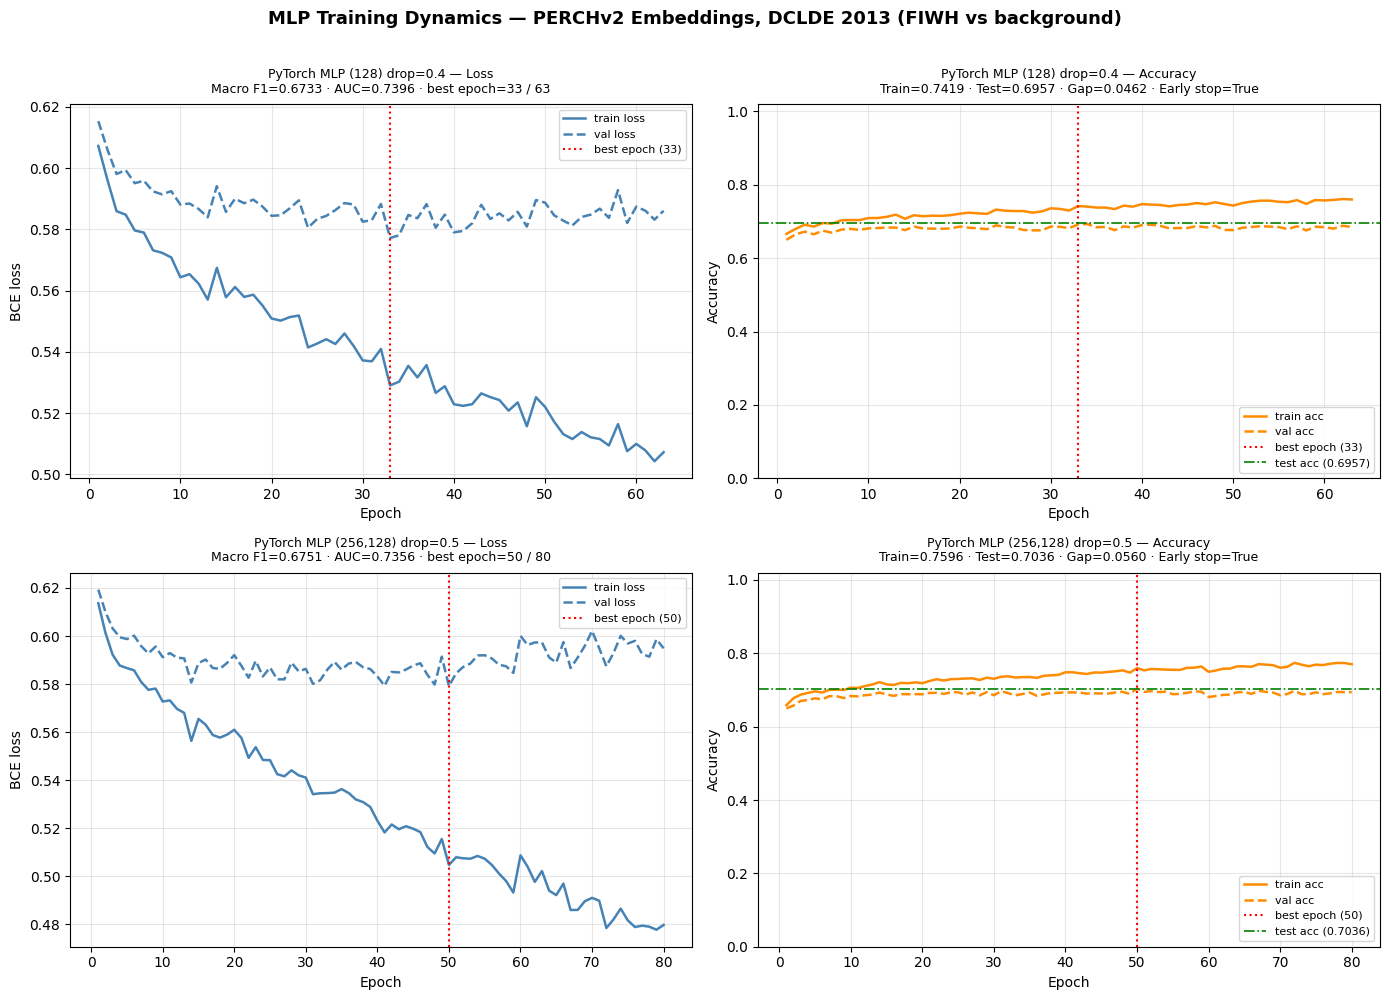

Saved → /data2/mromaniuc/cet-det/models/perch_v2/DCLDE_2013/figures/mlp_training_curves_dclde2013.png


In [22]:
#@title MLP Training Curves — DCLDE 2013 (binary)
import matplotlib.pyplot as plt
import numpy as np
import os

n_models = len(mlp_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

fig.suptitle('MLP Training Dynamics — PERCHv2 Embeddings, DCLDE 2013 (FIWH vs background)',
             fontsize=13, fontweight='bold', y=0.995)

for idx, (name, res) in enumerate(mlp_results.items()):
    ax_loss = axes[idx, 0]
    ax_acc  = axes[idx, 1]

    epochs = np.arange(1, res['n_iter'] + 1)

    # ── Loss ──────────────────────────────────────────────────────────────
    ax_loss.plot(epochs, res['train_losses'],
                 color='steelblue', linewidth=1.8, label='train loss')
    ax_loss.plot(epochs, res['val_losses'],
                 color='steelblue', linewidth=1.8, linestyle='--', label='val loss')
    ax_loss.axvline(res['best_epoch'], color='red', linestyle=':',
                    linewidth=1.5, label=f'best epoch ({res["best_epoch"]})')

    ax_loss.set_title(
        f'{name} — Loss\n'
        f'Macro F1={res["f1_macro"]:.4f} · AUC={res["auc"]:.4f} · '
        f'best epoch={res["best_epoch"]} / {res["n_iter"]}',
        fontsize=9, pad=8
    )
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('BCE loss')
    ax_loss.legend(fontsize=8, loc='upper right')
    ax_loss.grid(alpha=0.3)

    # ── Accuracy ──────────────────────────────────────────────────────────
    ax_acc.plot(epochs, res['train_accs'],
                color='darkorange', linewidth=1.8, label='train acc')
    ax_acc.plot(epochs, res['val_accs'],
                color='darkorange', linewidth=1.8, linestyle='--', label='val acc')
    ax_acc.axvline(res['best_epoch'], color='red', linestyle=':',
                   linewidth=1.5, label=f'best epoch ({res["best_epoch"]})')
    ax_acc.axhline(res['test_acc'], color='green', linestyle='-.',
                   linewidth=1.2, label=f'test acc ({res["test_acc"]:.4f})')

    ax_acc.set_title(
        f'{name} — Accuracy\n'
        f'Train={res["train_acc"]:.4f} · Test={res["test_acc"]:.4f} · '
        f'Gap={abs(res["train_acc"] - res["test_acc"]):.4f} · '
        f'Early stop={res["early_stopped"]}',
        fontsize=9, pad=8
    )
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8, loc='lower right')
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.0, 1.02)

plt.tight_layout(rect=[0, 0, 1, 0.985])
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/mlp_training_curves_dclde2013.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_dir}/figures/mlp_training_curves_dclde2013.png')

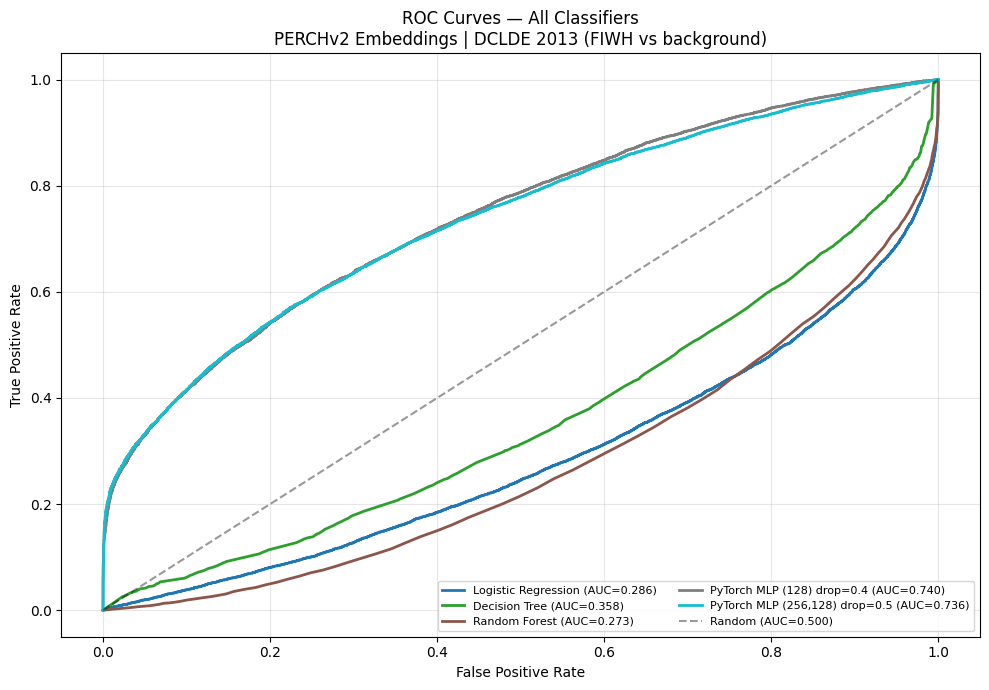

Saved → /data2/mromaniuc/cet-det/models/perch_v2/DCLDE_2013/figures/roc_curves.png


In [23]:
#@title ROC Curves — ALL Classifiers (including MLPs)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import os

# merge sklearn results + mlp results
all_results = {}
if 'results' in dir():
    all_results.update(results)
if 'mlp_results' in dir():
    all_results.update(mlp_results)

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for idx, (name, res) in enumerate(all_results.items()):
    if 'y_proba' not in res:
        continue
    try:
        fpr, tpr, _ = roc_curve(y_test_bin, res['y_proba'])
        auc          = roc_auc_score(y_test_bin, res['y_proba'])
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                 color=colors[idx], linewidth=2)
    except Exception as e:
        print(f'  Skipping {name}: {e}')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Classifiers\nPERCHv2 Embeddings | DCLDE 2013 (FIWH vs background)')
plt.legend(loc='lower right', fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()

os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_dir}/figures/roc_curves.png')

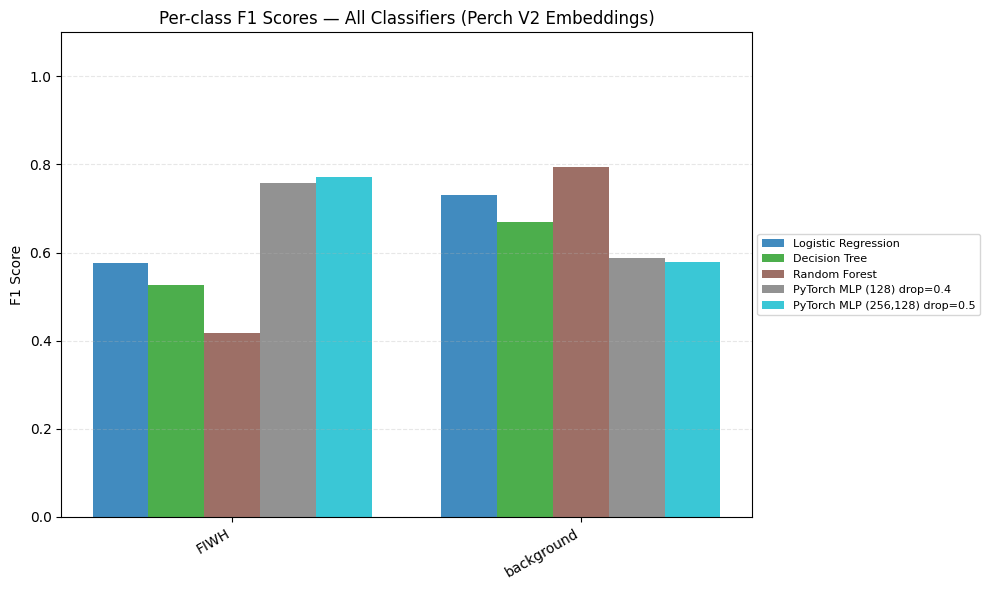

In [24]:
#@title Per-class F1 comparison bar chart — ALL classifiers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

classifier_names = list(results.keys())
n_classifiers = len(classifier_names)
n_classes = len(class_names)

colors = plt.cm.tab10(np.linspace(0, 1, min(n_classifiers, 10)))
x = np.arange(n_classes)
width = 0.8 / n_classifiers

fig, ax = plt.subplots(figsize=(max(10, n_classes * 1.5), 6))

for i, (name, res) in enumerate(results.items()):
    # PyTorch results use binary int preds; sklearn use encoded class indices
    y_true = y_test_bin.astype(int) if name.startswith('PyTorch') else y_test
    f1_per_class = f1_score(y_true, res['y_pred'],
                            labels=list(range(n_classes)), average=None, zero_division=0)
    offset = (i - n_classifiers/2 + 0.5) * width
    ax.bar(x + offset, f1_per_class, width, label=name,
           color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Scores — All Classifiers (Perch V2 Embeddings)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
#@title Save full results to CSV — ALL classifiers
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# Prepare rows for CSV
rows = []
for name, res in results.items():
    auc = roc_auc_score(y_test, res['y_proba']) if 'y_proba' in res else None
    p, r, f, s = precision_recall_fscore_support(
        y_test, res['y_pred'], labels=range(len(class_names)), zero_division=0
    )
    row = {
        'classifier': name,
        'macro_f1': res['f1_macro'],
        'time_seconds': res['time_s'],
        'roc_auc': auc
    }
    # Add per-class metrics
    for i, cls in enumerate(class_names):
        row[f'{cls}_precision'] = round(p[i], 3)
        row[f'{cls}_recall'] = round(r[i], 3)
        row[f'{cls}_f1'] = round(f[i], 3)
    # Optional: add support (sample count) once
    if 'support' not in row:
        for i, cls in enumerate(class_names):
            row[f'{cls}_support'] = s[i]
    rows.append(row)

results_df = pd.DataFrame(rows)
# Reorder columns for readability
cols = ['classifier', 'macro_f1', 'time_seconds'] + \
       [c for c in results_df.columns if c not in ['classifier', 'macro_f1', 'time_seconds']]
results_df = results_df[cols]

results_df.to_csv('perch_v2_all_classifiers_results_2.csv', index=False)
print(f'✅ Saved {len(results_df)} classifiers to perch_v2_all_classifiers_results.csv')
display(results_df.round(3))

✅ Saved 5 classifiers to perch_v2_all_classifiers_results.csv


,classifier,macro_f1,time_seconds,roc_auc,FIWH_precision,FIWH_recall,FIWH_f1,background_precision,background_recall,background_f1,FIWH_support,background_support
0,Logistic Regression,0.654,28.416,0.714,0.566,0.586,0.576,0.740,0.724,0.732,13816,22472
1,Decision Tree,0.598,173.566,0.642,0.490,0.567,0.526,0.705,0.637,0.669,13816,22472
2,Random Forest,0.606,28.232,0.727,0.773,0.286,0.418,0.684,0.948,0.794,13816,22472
3,PyTorch MLP (128) drop=0.4,0.673,109.703,0.260,0.255,0.430,0.320,0.393,0.227,0.288,13816,22472
4,"PyTorch MLP (256,128) drop=0.5",0.675,143.239,0.264,0.261,0.464,0.335,0.370,0.193,0.254,13816,22472


Running full PCA...

Total components: 1536

PCA Variance Explained (first 30 components):
Component  Variance Explained (%)  Cumulative (%)
      PC1                 12.4789         12.4789
      PC2                 10.3064         22.7854
      PC3                  6.6080         29.3933
      PC4                  5.3413         34.7347
      PC5                  4.8057         39.5404
      PC6                  4.3033         43.8437
      PC7                  3.8887         47.7324
      PC8                  3.1063         50.8387
      PC9                  2.5847         53.4234
     PC10                  2.2977         55.7212
     PC11                  2.0814         57.8025
     PC12                  1.9608         59.7633
     PC13                  1.7273         61.4906
     PC14                  1.6672         63.1578
     PC15                  1.4430         64.6009
     PC16                  1.1931         65.7940
     PC17                  1.1676         66.9616
     PC18

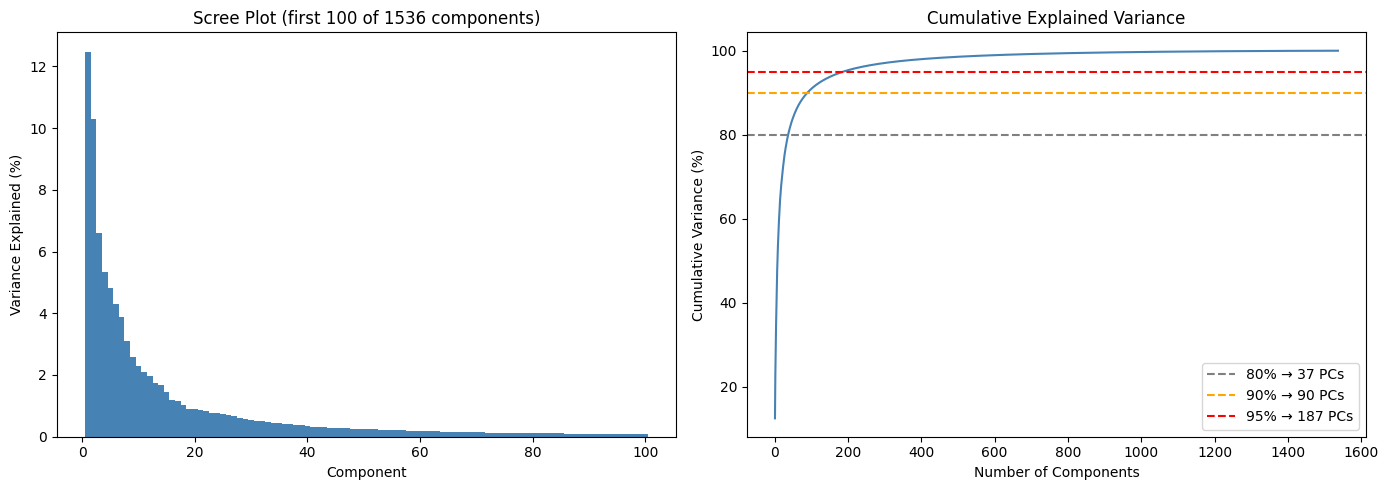

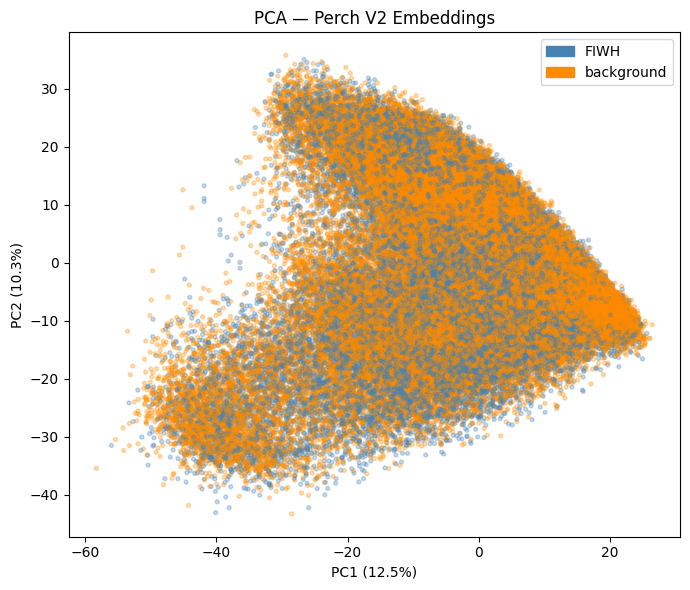


PCA-reduced shape for t-SNE/UMAP input: (120960, 90)

Running UMAP with multiple distance metrics...
  UMAP metric: euclidean...
  UMAP metric: cosine...
  UMAP metric: manhattan...
  UMAP metric: correlation...


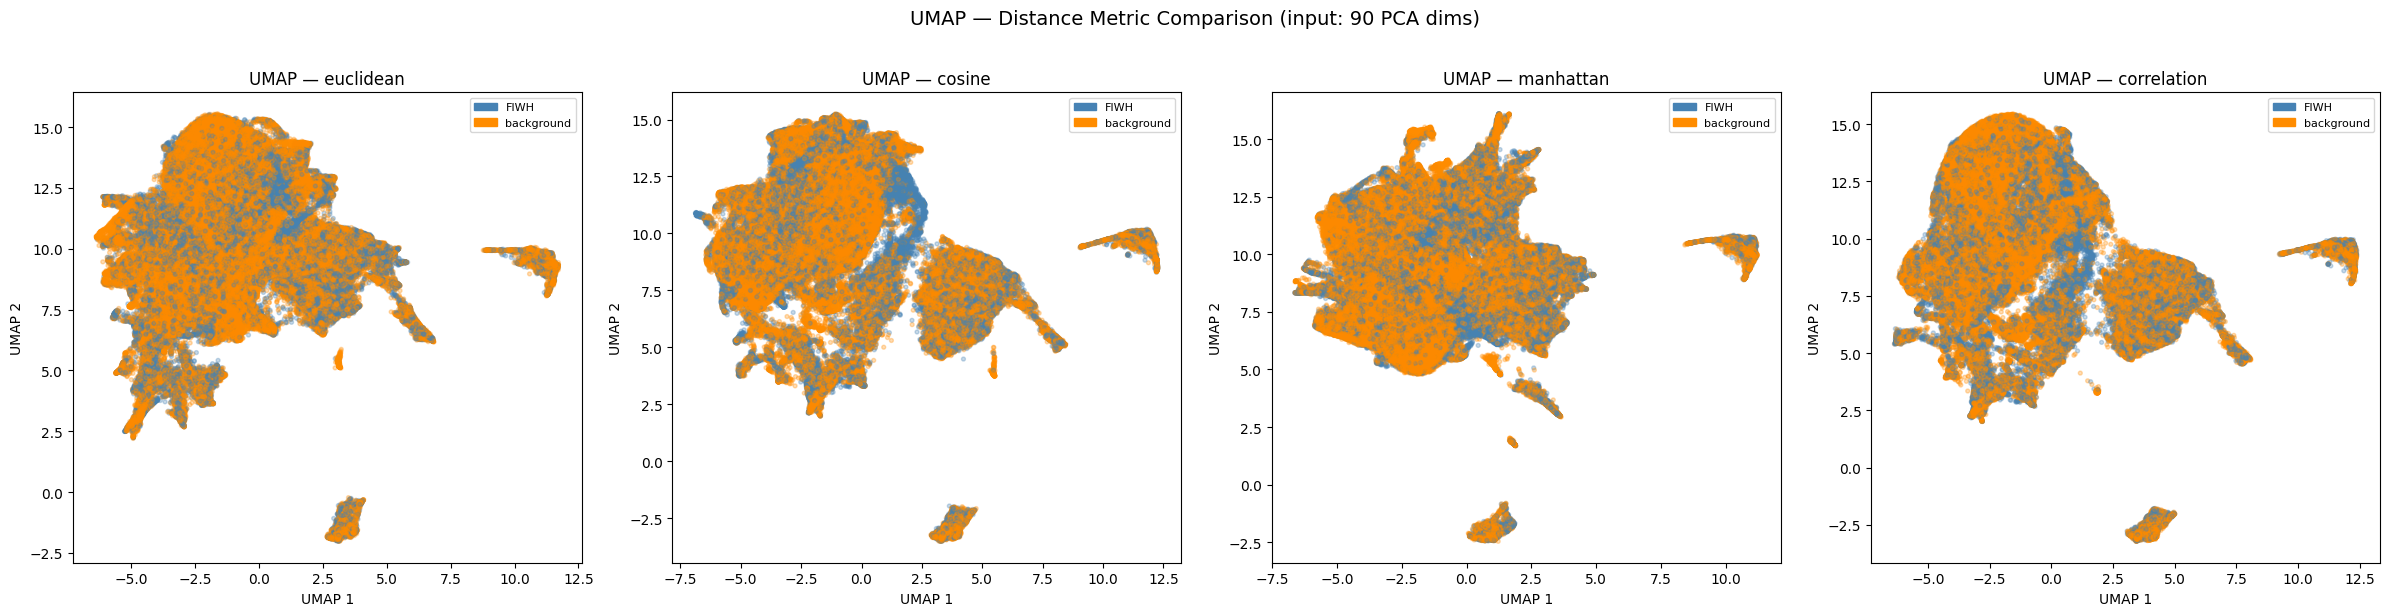

In [15]:
#@title Dimensionality reduction — Full PCA analysis + multi-metric t-SNE & UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Standardize embeddings
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

# Color setup
colors = {'FIWH': 'steelblue', 'background': 'darkorange'}
c = np.array([colors[label] for label in y_clean])
alpha = 0.3
s = 8
legend_patches = [
    mpatches.Patch(color='steelblue', label='FIWH'),
    mpatches.Patch(color='darkorange', label='background')
]

# ═══════════════════════════════════════════════════════════════════════════════
# 1. FULL PCA — Variance analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Variance table — all components
var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_total)],
    'Variance Explained (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative (%)': cumvar_full
})

# Print first 30 components
print(f'\nTotal components: {n_total}')
print(f'\nPCA Variance Explained (first 30 components):')
print(var_df.head(30).to_string(index=False, float_format='%.4f'))

# Key thresholds
n80 = np.argmax(cumvar_full >= 80) + 1
n90 = np.argmax(cumvar_full >= 90) + 1
n95 = np.argmax(cumvar_full >= 95) + 1
n99 = np.argmax(cumvar_full >= 99) + 1
print(f'\nComponents for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')

# Choose n_components for t-SNE input — 90% variance is a good default
n_pca = n90
print(f'\n→ Using {n_pca} PCA components for t-SNE input (90% variance)')

# Scree plot + cumulative (R-style)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree — individual variance per component (zoom to first 100)
n_show = min(100, n_total)
ax1.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='steelblue', width=1.0)
ax1.set_xlabel('Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title(f'Scree Plot (first {n_show} of {n_total} components)')

# Cumulative
ax2.plot(range(1, n_total + 1), cumvar_full, color='steelblue')
ax2.axhline(80, color='gray', linestyle='--', label=f'80% → {n80} PCs')
ax2.axhline(90, color='orange', linestyle='--', label=f'90% → {n90} PCs')
ax2.axhline(95, color='red', linestyle='--', label=f'95% → {n95} PCs')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_full_variance.png', dpi=150)
plt.show()

# PCA 2D scatter
pca2 = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Perch V2 Embeddings')
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d.png', dpi=150)
plt.show()

metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PCA-reduce for t-SNE and UMAP input (consistent input for both)
# ═══════════════════════════════════════════════════════════════════════════════
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)
print(f'\nPCA-reduced shape for t-SNE/UMAP input: {X_pca_red.shape}')


# ═══════════════════════════════════════════════════════════════════════════════
# 4. UMAP — Multiple distance metrics (same PCA input for fair comparison)
# ═══════════════════════════════════════════════════════════════════════════════
print('\nRunning UMAP with multiple distance metrics...')
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
umap_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  UMAP metric: {metric}...')
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        n_components=2,
        metric=metric,
        random_state=random_seed,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_pca_red)
    umap_results[metric] = X_umap

    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(handles=legend_patches, fontsize=8)

plt.suptitle(f'UMAP — Distance Metric Comparison (input: {n_pca} PCA dims)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5. Summary
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'PCA input dims: {X_scaled.shape[1]} → reduced to {n_pca} (90% variance)')


# ── Save all coordinates ────────────────────────────────────────────────────
np.save(f'{save_dir}/dim_red/coords_pca2.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}.npy', umap_results[metric])
print('\nAll coordinates saved.')


SUMMARY
PCA input dims: 1536 → reduced to 90 (90% variance)

All coordinates saved.


: 